Simulate the shot noise directly, holding $<V> = 10 mV$ and $\tau = 20 ms$ fixed while taking $ν\tau = 2, 20, 200$ with $w$ set accordingly. Report the measured mean, variance, and skewness against theory in a table. For the two extreme cases $ν\tau = 2$ and $200$ only, overlay the voltage histogram with the matched Gaussian.

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import skew, norm

# Equation parameters
tau = 0.020     # s
mean_V = 10.0   # mV
nu_tau_values = [2, 20, 200]
dt = 0.0001
T = 100     # simulation time
discard = 2.5   # discard the initial transient before collecting data
steps = int(T / dt)
discard_steps = int(discard / dt)
randnum = np.random.default_rng(1)

# shot noise sim setup
def simulate_shot_noise(nu_tau_values):
    nu = nu_tau_values / tau
    w = mean_v / nu_tau_values
    V = np.zeros(steps)
    p = nu * dt

    for i in range(1, steps):
        Kn = randnum.poisson(p)
        V[i] = V[i - 1] * np.exp(-dt / tau) + w * Kn

    transient = V[discard_steps:]
    return transient, nu, w

# run sim
results = []

for nu_tau in nu_tau_values:
        V, nu, w = simulate_shot_noise(nu_tau)
        measured_mean = np.mean(V)
        measured_var = np.var(V)
        measured_skew = skew(V)

        theory_mean = mean_v
        theory_var = w ** 2 * nu_tau / 2
        theory_skew = 2 * np.sqrt(2) / (3 * np.sqrt(nu_tau))

        results.append({
            "nu_tau": nu_tau, 
            "nu (Hz)": nu,
            "w (mV)": w, 
            "Measured Mean": measured_mean,
            "Theoretical Mean": theory_mean, 
            "Measured Variance": measured_var,
            "Theoretical Variance": theory_var,
            "Measured Skew": measured_skew,
            "Theoretical Skew": theory_skew
        })

# Build Table
df = pd.DataFrame(results)
df.style.format({
    "nu_tau": "{:.4f}",
    "nu (Hz)": "{:.4f}",
    "w (mV)": "{:.4f}",
    "Measured Mean": "{:.4f}",
    "Theoretical Mean": "{:.4f}", 
    "Measured Variance": "{:.4f}", 
    "Theoretical Variance": "{:.4f}", 
    "Measured Skew": "{:.4f}", 
    "Theoretical Skew": "{:.4f}",
})



,nu_tau,nu (Hz),w (mV),Measured Mean,Theoretical Mean,Measured Variance,Theoretical Variance,Measured Skew,Theoretical Skew
0,2.0000,100.0000,5.0000,10.0842,10.0000,24.8978,25.0000,0.6561,0.6667
1,20.0000,1000.0000,0.5000,10.0028,10.0000,2.4924,2.5000,0.1727,0.2108
2,200.0000,10000.0000,0.0500,10.0314,10.0000,0.2511,0.2500,0.0934,0.0667


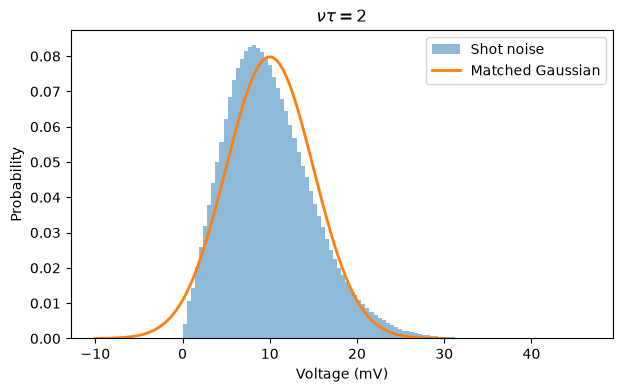

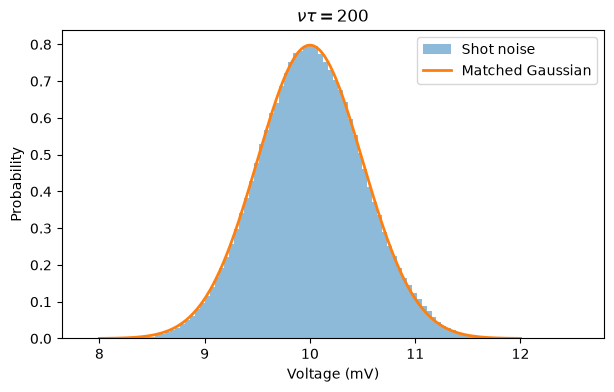

In [19]:
# Histogram
for nu_tau in [2, 200]:
    V, nu, w = simulate_shot_noise(nu_tau)
    theory_mean = mean_v
    theory_var = w ** 2 * nu_tau / 2
    stdev = np.sqrt(theory_var)

    plt.figure(figsize = (7, 4))
    plt.hist(
        V,
        bins = 100, 
        density = True, 
        alpha = 0.5, 
        label = "Shot noise"
    )

    x = np.linspace(
        theory_mean - 4 * stdev,
        theory_mean + 4 * stdev, 
        500
    )

    gaussian = norm.pdf(x, theory_mean, stdev)

    plt.plot(
        x, 
        gaussian,
        linewidth = 2, 
        label = "Matched Gaussian"
    )

    plt.xlabel("Voltage (mV)")
    plt.ylabel("Probability")
    plt.title(rf"$\nu\tau = {nu_tau}$")
    plt.legend()
    plt.show()